Epoch 100/1000, Loss: 0.0324
Epoch 200/1000, Loss: 0.0208
Epoch 300/1000, Loss: 0.0163
Epoch 400/1000, Loss: 0.0139
Epoch 500/1000, Loss: 0.0122
Epoch 600/1000, Loss: 0.0111
Epoch 700/1000, Loss: 0.0102
Epoch 800/1000, Loss: 0.0095
Epoch 900/1000, Loss: 0.0090
Epoch 1000/1000, Loss: 0.0085

Test Accuracy: 1.0000


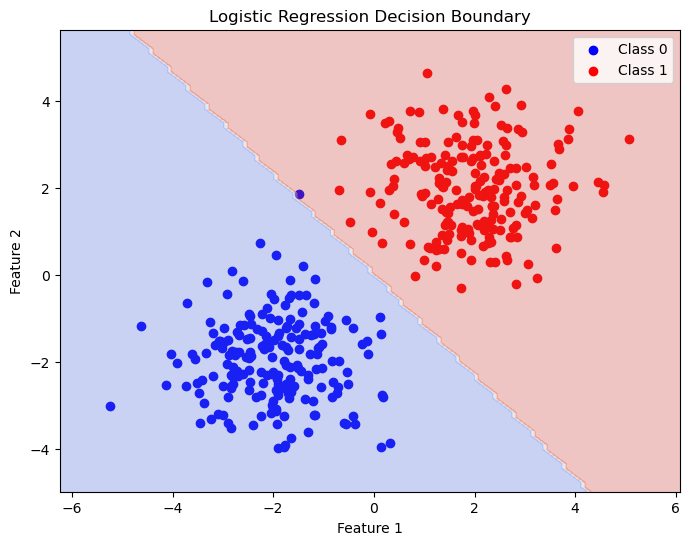

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 1. 生成线性可分数据 ----------------------
np.random.seed(42)

# 每类200个样本，特征维度为2
n_samples = 200
# 类别0：均值为(-2, -2)，方差为1
X0 = np.random.randn(n_samples, 2) + np.array([-2, -2])
y0 = np.zeros((n_samples, 1))
# 类别1：均值为(2, 2)，方差为1
X1 = np.random.randn(n_samples, 2) + np.array([2, 2])
y1 = np.ones((n_samples, 1))

# 合并数据
X = np.vstack((X0, X1))
y = np.vstack((y0, y1))

# 划分训练集和测试集（这里训练集就是生成的400个样本，测试集后续生成）
X_train, y_train = X, y

# ---------------------- 2. 定义sigmoid和二元交叉熵损失 ----------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    m = y_true.shape[0]
    # 防止log(0)
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# ---------------------- 3. 梯度下降训练 ----------------------
# 初始化参数
n_features = X_train.shape[1]
w = np.zeros((n_features, 1))
b = 0.0
lr = 0.1
epochs = 1000

for epoch in range(epochs):
    # 前向传播
    z = X_train @ w + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_pred, y_train)
    
    # 反向传播（梯度计算）
    dw = (X_train.T @ (y_pred - y_train)) / X_train.shape[0]
    db = np.mean(y_pred - y_train)
    
    # 更新参数
    w -= lr * dw
    b -= lr * db
    
    # 每100轮打印一次损失
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

# ---------------------- 4. 绘制决策边界 + 测试集准确率 ----------------------
# 生成测试集：100个样本
n_test = 100
X0_test = np.random.randn(n_test//2, 2) + np.array([-2, -2])
X1_test = np.random.randn(n_test//2, 2) + np.array([2, 2])
X_test = np.vstack((X0_test, X1_test))
y_test = np.vstack((np.zeros((n_test//2, 1)), np.ones((n_test//2, 1))))

# 测试集预测
z_test = X_test @ w + b
y_test_pred = sigmoid(z_test)
y_test_pred_labels = (y_test_pred > 0.5).astype(int)
accuracy = np.mean(y_test_pred_labels == y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")

# 绘制决策边界
plt.figure(figsize=(8, 6))
# 绘制训练集数据点
plt.scatter(X0[:, 0], X0[:, 1], c='blue', label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], c='red', label='Class 1')

# 决策边界：w1*x1 + w2*x2 + b = 0
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                       np.linspace(x2_min, x2_max, 100))
Z = sigmoid(xx1 * w[0,0] + xx2 * w[1,0] + b)
Z = (Z > 0.5).astype(int)
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap='coolwarm')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()